In [32]:
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from pathlib import Path
import os, re
from pydantic import BaseModel
load_dotenv()

True

In [3]:
docs = []
for pdf_file in Path("./documents").glob("*.pdf"):
    docs.extend(PyPDFLoader(str(pdf_file)).load())

In [4]:
len(docs)

2123

In [5]:
# create smaller chunks from documents
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

# to avoid unicode errors
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [6]:
len(chunks)

6396

In [17]:
# embed docs and create vector store
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

if os.path.exists("faiss_index"):
    vector_store = FAISS.load_local(
        "faiss_index",
        embeddings,
        allow_dangerous_deserialization=True
    )
    print("Loaded existing FAISS index.")
else:
    print("here")
    vector_store = FAISS.from_documents(chunks, embeddings)
    vector_store.save_local("faiss_index")
    print("Created and saved new FAISS index.")

Loaded existing FAISS index.


In [18]:
if not os.path.exists("faiss_index"):
  vector_store.save_local("faiss_index")

In [19]:
# retriever
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [20]:
# LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [42]:
class State(TypedDict):
    question: str
    docs: List[Document]
    strips: List[str]
    kept_strips: List[str]
    refined_context: str
    answer: str

In [43]:
# retrieve the relevant docs from vector store
def retrieve(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [44]:
# Sentence-level DECOMPOSER
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

In [45]:
class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

In [46]:
# refine the retrived docs
def refine(state: State) -> State:

    q = state["question"]

    # Combine retrieved docs into one context string
    context = "\n\n".join(d.page_content for d in state["docs"]).strip()

    # DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # FILTER: keep only relevant strips
    kept: List[str] = []
    
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

In [47]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state):
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": out.content}

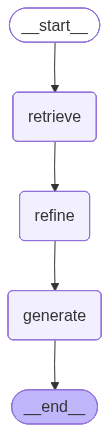

In [48]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("refine", refine)
g.add_node("generate", generate)
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "refine")
g.add_edge("refine", "generate")
g.add_edge("generate", END)
app = g.compile()

app

In [49]:
res = app.invoke({
    "question": "Explain the bias–variance tradeoff",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})
print(res["answer"])

The bias–variance tradeoff is a fundamental concept in statistics and machine learning that describes the relationship between a model's complexity and its generalization error. 

- **Bias**: This error arises from incorrect assumptions in the learning algorithm, such as assuming linearity when the data is actually quadratic. High-bias models tend to underfit the training data.
  
- **Variance**: This error is due to the model's sensitivity to small fluctuations in the training data. High-variance models can overfit the training data.

- The generalization error can be expressed as the sum of bias, variance, and a constant noise term.

- There is a trade-off between bias and variance: flexible models have low bias and high variance, while rigid models have high bias and low variance.

- The optimal model achieves the best balance between bias and variance.

- Increasing model complexity typically raises variance and lowers bias, while decreasing complexity raises bias and lowers varian

In [53]:
# for doc in res['docs']:
#   print(doc.page_content)
#   print('*'*100)

print("------- Refined context ----------")
for doc in res['refined_context'].split("\n"):
  print(doc)
  print('*'*100)

------- Refined context ----------
The Bias/Variance Tradeoff An importan t theoretical result of statistics and Machine Learning is the fact that a model’s generaliza tion error can be expressed as the sum of three very different errors: Bias This part of the generalization error is due to wrong assumptions, such as assum‐ ing that the data is linear when it is actually quadratic.
****************************************************************************************************
A high-bias model is most likely to underfit the training data.10 Variance This part is due to the model’s excessive sensitivity to small variations in the training data.
****************************************************************************************************
Our goal is to minimize the expected loss, which we have decomposed into the sum of a (squared) bias, a variance, and a constant noise term.
****************************************************************************************************
